Задания для самостоятельной работы.

Часть 1. Бинаризация, фильтрация, разметка.

Загрузите изображение риса «rice.png».

Бинаризуйте и отфильтруйте его, выполните разметку.

Посчитайте, сколько всего зёрен риса содержит изображение.

Выведите на экран зерно, номер которого равен вашему номеру по журналу, умноженному на пять.

Найдите изображения рисинок, которые склеились в один объект и подлежат разделению.

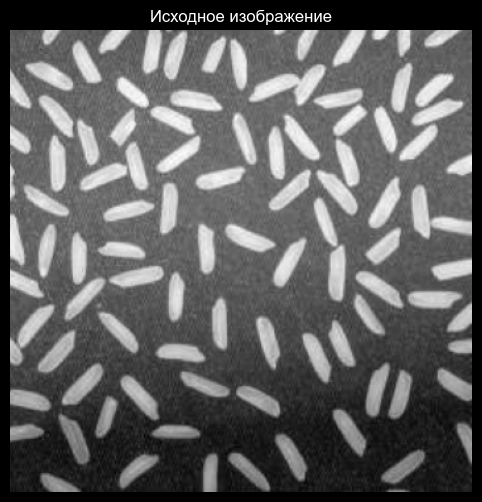

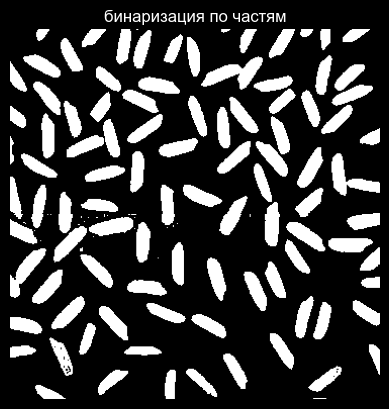

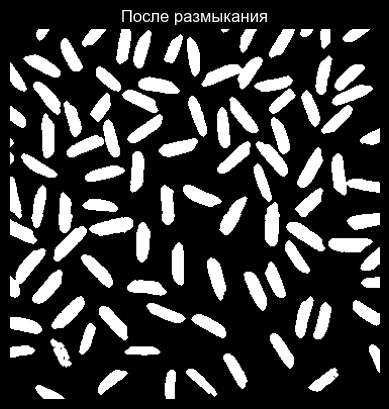

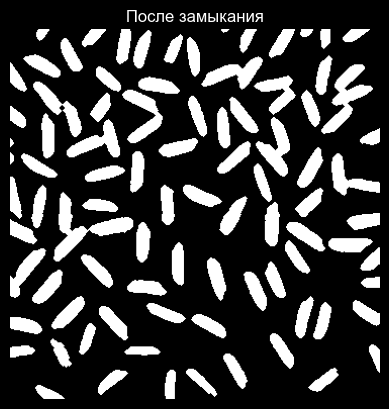

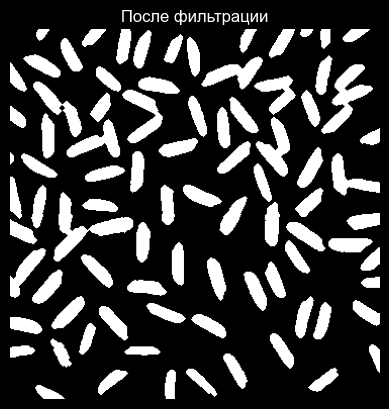

Всего зёрен риса на изображении: 86


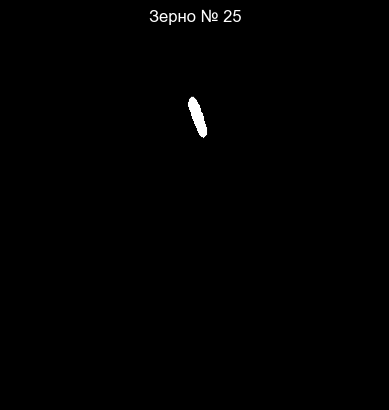

Найдено 10 склеенных объектов (номера: [15 17 19 21 22 30 31 39 47 59])


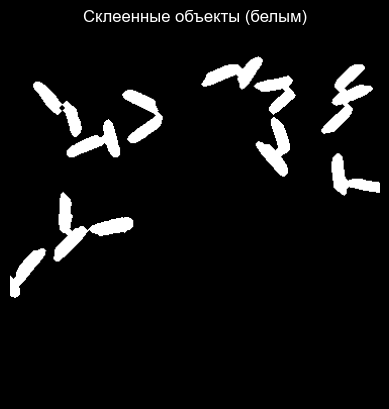

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure, morphology
from scipy import ndimage

# ----------------------------------------------
# 1. Загрузка изображения в градациях серого
# ----------------------------------------------
A = cv2.imread('rice.png', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(8,6))
plt.imshow(A, cmap='gray'), plt.title('Исходное изображение')
plt.axis('off')
plt.show()

# ----------------------------------------------
# 2. Бинаризация
# ----------------------------------------------
# Локальная бинаризация (разделение на верхнюю и нижнюю части)
h, w = A.shape
A1 = A[0:int(h/2), :]        # верхняя половина
A2 = A[int(h/2):, :]         # нижняя половина

_, B1 = cv2.threshold(A1, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, B2 = cv2.threshold(A2, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Склейка
binary = np.zeros_like(A, dtype=np.uint8)
binary[0:int(h/2), :] = B1
binary[int(h/2):, :] = B2

plt.figure()
plt.imshow(binary, cmap='gray'), plt.title('бинаризация по частям')
plt.axis('off')
plt.show()

# ----------------------------------------------
# 3. Морфологическая фильтрация для удаления шума и заполнения дырок
# ----------------------------------------------

# Открытие – удаляем мелкие шумовые точки на фоне
kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_open, iterations=2)

plt.figure()
plt.imshow(opened, cmap='gray'), plt.title('После размыкания')
plt.axis('off')
plt.show()

# Закрытие – заполняем небольшие дыры внутри зёрен
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_close, iterations=2)

plt.figure()
plt.imshow(closed, cmap='gray'), plt.title('После замыкания')
plt.axis('off')
plt.show()

# Удаляем объекты размером меньше 30 пикселей (ложные срабатывания)
from skimage.morphology import remove_small_objects
closed_bool = closed.astype(bool)
cleaned = remove_small_objects(closed_bool, max_size=30).astype(np.uint8) * 255

plt.figure()
plt.imshow(cleaned, cmap='gray'), plt.title('После фильтрации')
plt.axis('off')
plt.show()

# ----------------------------------------------
# 4. Разметка объектов (подсчёт зёрен)
# ----------------------------------------------
labeled = measure.label(cleaned, connectivity=2)   # метки от 0 (фон) до N
num_grains = np.max(labeled)
print(f'Всего зёрен риса на изображении: {num_grains}')

# ----------------------------------------------
# 5. Вывод зерна под номером 25
# ----------------------------------------------
target_id = 25
if target_id <= num_grains:
    mask_25 = (labeled == target_id).astype(np.uint8) * 255
    plt.figure()
    plt.imshow(mask_25, cmap='gray'), plt.title(f'Зерно № {target_id}')
    plt.axis('off')
    plt.show()
else:
    print(f'Зерна с номером {target_id} не существует (всего {num_grains}).')

# ----------------------------------------------
# 6. Поиск склеенных зёрен (объекты аномально большой площади)
# ----------------------------------------------
# Вычисляем площади всех объектов (исключая фон)
areas = np.bincount(labeled.ravel())
areas = areas[1:]   # убираем фон

# Вычислим порог: медиана + 2 * (медианное абсолютное отклонение)
median_area = np.median(areas)
mad = np.median(np.abs(areas - median_area))
threshold = median_area + 2 * mad

# Находим номера объектов, площадь которых превышает порог
suspicious_ids = np.where(areas > threshold)[0] + 1   # +1 т.к. индексы начинаются с 0, а метки с 1

if len(suspicious_ids) > 0:
    print(f'Найдено {len(suspicious_ids)} склеенных объектов (номера: {suspicious_ids})')
    # Визуализируем их на одном изображении
    suspicious_mask = np.zeros_like(labeled, dtype=np.uint8)
    for idx in suspicious_ids:
        suspicious_mask[labeled == idx] = 255
    plt.figure()
    plt.imshow(suspicious_mask, cmap='gray'), plt.title('Склеенные объекты (белым)')
    plt.axis('off')
    plt.show()
else:
    print('Склеенных объектов не обнаружено.')

# размеченное изображение (цветная карта)
# plt.figure(figsize=(10,8))
# plt.imshow(labeled, cmap='tab20'), plt.title('Разметка всех зёрен')
# plt.axis('off')
# plt.show()

Часть 2. Характеристики бинарных объектов.

Откройте редактор mspaint, нарисуйте изображение нескольких деталей.

Одна из деталей должна иметь форму правильного пятиугольника.

Одна из деталей должна содержать четыре отверстия.

Пользуясь методами, изученными в лабораторной работе, напишите скрипт, который позволяет найти и закрасить на изображении пятиугольную деталь красным цветом, а деталь с четырьмя отверстиями – зеленым.

Найдено объектов: 8
Объект 1: отверстий=0, вершин=6
Объект 2: отверстий=1, вершин=5
Объект 3: отверстий=4, вершин=4
Объект 4: отверстий=0, вершин=5
Объект 5: отверстий=4, вершин=4
Объект 6: отверстий=0, вершин=6
Объект 7: отверстий=0, вершин=5
Объект 8: отверстий=1, вершин=10


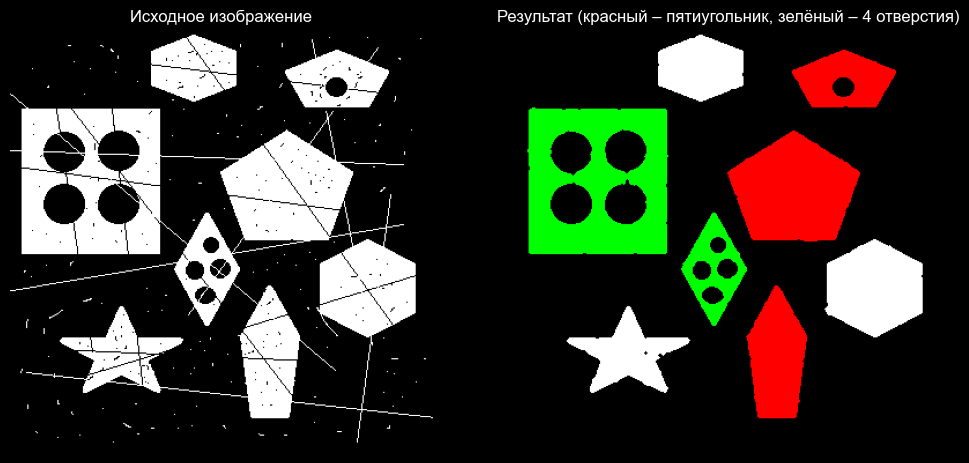

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure, morphology
from skimage.measure import regionprops

# -------------------- Загрузка и предобработка --------------------
img_path = 'detal_super_test.bmp'
img_color = cv2.imread(img_path)
if img_color is None:
    raise FileNotFoundError("Файл не найден")
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# Бинаризация (метод Отсу, объекты – чёрные на белом, поэтому инвертируем)
# _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Мягкая очистка – медианный фильтр и удаление мелкого шума
binary = cv2.medianBlur(gray, 3)
# Удаление объектов малой площади (ложные срабатывания)
from skimage.morphology import remove_small_objects
cleaned = remove_small_objects(binary.astype(bool), max_size=50).astype(np.uint8) * 255

# Морфологическое размыкание (удаление фоновых точек) – минимальное
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
opened = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel, iterations=1)
# Закрытие – для заполнения мелких разрывов (можно убрать, если не нужно)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=1)

# Финальная очистка
final = remove_small_objects(closed.astype(bool), max_size=30).astype(np.uint8) * 255

# -------------------- Разметка и анализ --------------------
labeled = measure.label(final, connectivity=2)
num_objects = np.max(labeled)
print(f"Найдено объектов: {num_objects}")

result = cv2.cvtColor(final, cv2.COLOR_RGB2BGR)

for obj_id in range(1, num_objects + 1):
    mask = (labeled == obj_id).astype(np.uint8) * 255

    # 1. Подсчёт отверстий через regionprops
    props = regionprops(mask.astype(int))
    if not props:
        continue
    euler = props[0].euler_number
    holes = 1 - euler  # количество дыр

    # 2. Определение формы (аппроксимация контура)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cnt = max(contours, key=cv2.contourArea)
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
        vertices = len(approx)
    else:
        vertices = 0

    print(f"Объект {obj_id}: отверстий={holes}, вершин={vertices}")

    # Определяем цвет
    color = None
    if holes == 4:
        color = (0, 255, 0)   # зелёный
    elif vertices == 5:
        color = (255, 0, 0)   # красный

    if color is not None:
        result[mask > 0] = color

# -------------------- Отображение --------------------
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_rgb), plt.title('Исходное изображение'), plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(result), plt.title('Результат (красный – пятиугольник, зелёный – 4 отверстия)'), plt.axis('off')
plt.show()